## Problem 2 - SOFM

In [2]:
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import random
from sklearn.decomposition import PCA

In [4]:
labels = []
numbers = []

with open(os.path.join(os.getcwd(), 'data/MNISTnumLabels5000_balanced.txt'), 'r+') as f:
    lines = f.readlines()
    for line in lines:
        labels.append(int(line))

with open(os.path.join(os.getcwd(), 'data/MNISTnumImages5000_balanced.txt'), 'r+') as f:
    lines = f.readlines()
    for line in lines:
        ind_line = line.split('\t')
        ind_line = [float(i) for i in ind_line]

        numbers.append(ind_line)
    

labels = np.array(labels)
numbers = np.array(numbers)

1


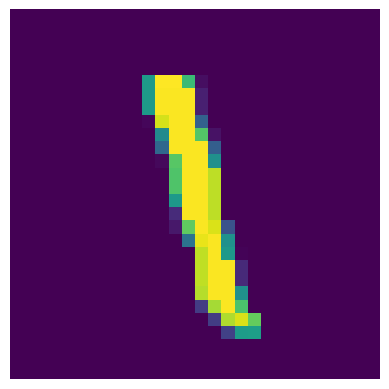

In [5]:
index = random.randint(0, 4999)

example_number = numbers[index]
example_label = labels[index]
matrix = example_number.reshape(28, 28).T

print(example_label)
plt.imshow(matrix)
plt.axis('off')
plt.show()

In [6]:
train_set = []
train_labels = []

test_set = []
test_labels = []

digits = {d: 0 for d in range(0, 10)}

for i in range(len(numbers)):
    label = labels[i]  # get the digit for this image
    
    if label in digits and digits[label] < 400:
        train_set.append(numbers[i])
        train_labels.append(label)
        digits[label] += 1
    else:
        test_set.append(numbers[i])
        test_labels.append(label)
        digits[label] += 1


train_set = np.array(train_set)
test_set = np.array(test_set)
train_labels = np.array(train_labels)
test_labels = np.array(test_labels)
# normalizing the datasets
train_set = train_set.astype(np.float32)
test_set = test_set.astype(np.float32)

combined_train_data = list(zip(train_labels, train_set))
random.shuffle(combined_train_data)

combined_test_data = list(zip(test_labels, test_set))
random.shuffle(combined_test_data)

print(len(combined_train_data), len(combined_test_data))

4000 1000


In [7]:
m, n = train_set.shape

X_train, X_test = train_set, test_set
Y_train, Y_test = train_labels, test_labels

_, m_train = X_train.shape
_, m_test = X_test.shape

In [11]:
# Shuffle training set
perm_train = np.random.permutation(X_train.shape[0])  # columns = samples
X_train = X_train[perm_train]
Y_train = np.array(Y_train)[perm_train]  

# Shuffle test set
perm_test = np.random.permutation(X_test.shape[0])
X_test = X_test[perm_test]
Y_test = np.array(Y_test)[perm_test]

X_train.shape, Y_train.shape

((4000, 784), (4000,))

### SOFM Implementation

In [14]:
class SOFM:
    def __init__(self, map_size=(12, 12), input_dim=784, alpha0=0.8, sigma0=7, epochs=100):
        self.rows, self.cols = map_size
        self.num_neurons = self.rows * self.cols
        self.input_dim = input_dim

        # Learning parameters
        self.alpha0 = alpha0
        self.sigma0 = sigma0
        self.epochs = epochs

        # Initialize random weights
        self.W = 0.01 * np.random.randn(self.num_neurons, self.input_dim) 

        # Store neuron (row, col) positions
        self.positions = np.array([(i // self.cols, i % self.cols) for i in range(self.num_neurons)])

    
    ### Helper Functions ###

    # Returns the index of the best matching neuron for input X
    # Uses euclidian distance
    def find_bmu(self, x):
        distances = np.linalg.norm(self.W - x, axis=1)
        return np.argmin(distances)

    # Compute neighborhood influence on all neurons
    # This helps the map gain a smooth organized layout,
    # Where similar inputs activate neighboring neurons instead of
    # random spots
    def neighborhood_influence(self, bmu_idx, sigma):
        bmu_pos = self.positions[bmu_idx]
        dists = np.linalg.norm(self.positions - bmu_pos, axis=1)
        return np.exp(-(dists ** 2) / (2 * (sigma ** 2)))


    ### Training Function ###

    def train(self, train_data):
        total_iterations = self.epochs * len(train_data)
        lambda_const = total_iterations / np.log(self.sigma0)
        iteration = 0

        train_data = train_data / (np.linalg.norm(train_data, axis=1, keepdims=True) + 1e-10)

        alpha = self.alpha0
        sigma = self.sigma0

        for epoch in range(self.epochs):
            # Decay learning rate + neighborhood radius
            print(f"Epoch {epoch+1}/{self.epochs} — alpha={alpha:.4f}, sigma={sigma:.4f}")

            # Shuffle training set for better training
            np.random.shuffle(train_data)

            for x in train_data:
                alpha = self.alpha0 * np.exp(-iteration / total_iterations)
                sigma = self.sigma0 * np.exp(-iteration / lambda_const)
                sigma = max(sigma, 0.5)
                bmu = self.find_bmu(x)
                h = self.neighborhood_influence(bmu, sigma)   # shape (num_neurons,)

                # Update all neurons
                self.W += (alpha * h[:, None]) * (x - self.W)
                iteration+=1

    
    ### Testing / Activity Maps ###
    def test(self, test_data, test_labels):
        class_activity = np.zeros((10, self.num_neurons))  # 10 classes
        
        for x, label in zip(test_data, test_labels):
            bmu = self.find_bmu(x)
            class_activity[label, bmu] += 1
        
        # Normalize by actual count per class (not hardcoded 100)
        for c in range(10):
            class_count = np.sum(class_activity[c])
            if class_count > 0:
                class_activity[c] /= class_count
        
        return class_activity
    
    ##    Plot 10 heatmaps (12×12) for classes 0–9.
    ##    Input: class_activity of shape (10, num_neurons)
    def plot_activity_maps(self, class_activity):
        fig, axes = plt.subplots(2, 5, figsize=(15, 6))

        for c in range(10):
            ax = axes[c // 5, c % 5]
            heatmap = class_activity[c].reshape(self.rows, self.cols)
            im = ax.imshow(heatmap, cmap='hot', interpolation='nearest')
            ax.set_title(f"Class {c}")
            ax.axis('off')

        plt.tight_layout()
        plt.show()


    ##    Plot the 12×12 grid of 28×28 neuron weight images.
    ##    Final image dimension = 336×336 (as required by assignment).
    def plot_weight_grid(self):
        fig, axes = plt.subplots(self.rows, self.cols, figsize=(10, 10))

        for i in range(self.num_neurons):
            r, c = i // self.cols, i % self.cols
            ax = axes[r, c]
            ax.imshow(self.W[i].reshape(28, 28), cmap='gray')
            ax.axis('off')

        plt.tight_layout()
        plt.show()
    
    def compute_neuron_overlaps(self, data, labels):
        neuron_to_classes = {i: [] for i in range(self.num_neurons)}

        for x, y in zip(data, labels):
            bmu = self.find_bmu(x)
            neuron_to_classes[bmu].append(int(y))

        mixed = 0
        per_neuron_info = {}

        for i in range(self.num_neurons):
            classes = set(neuron_to_classes[i])
            per_neuron_info[i] = classes
            if len(classes) > 1:
                mixed += 1

        return mixed, per_neuron_info


### Training and Testing Performance

In [15]:
som = SOFM(epochs=20, input_dim=784, sigma0=5, alpha0=0.1)

sofm = som.train(X_train)


Epoch 1/20 — alpha=0.1000, sigma=5.0000
Epoch 2/20 — alpha=0.0951, sigma=4.6135
Epoch 3/20 — alpha=0.0905, sigma=4.2568
Epoch 4/20 — alpha=0.0861, sigma=3.9277
Epoch 5/20 — alpha=0.0819, sigma=3.6240
Epoch 6/20 — alpha=0.0779, sigma=3.3438
Epoch 7/20 — alpha=0.0741, sigma=3.0852
Epoch 8/20 — alpha=0.0705, sigma=2.8467
Epoch 9/20 — alpha=0.0670, sigma=2.6266
Epoch 10/20 — alpha=0.0638, sigma=2.4235
Epoch 11/20 — alpha=0.0607, sigma=2.2361
Epoch 12/20 — alpha=0.0577, sigma=2.0632
Epoch 13/20 — alpha=0.0549, sigma=1.9037
Epoch 14/20 — alpha=0.0522, sigma=1.7565
Epoch 15/20 — alpha=0.0497, sigma=1.6207
Epoch 16/20 — alpha=0.0472, sigma=1.4954
Epoch 17/20 — alpha=0.0449, sigma=1.3798
Epoch 18/20 — alpha=0.0427, sigma=1.2731
Epoch 19/20 — alpha=0.0407, sigma=1.1746
Epoch 20/20 — alpha=0.0387, sigma=1.0838


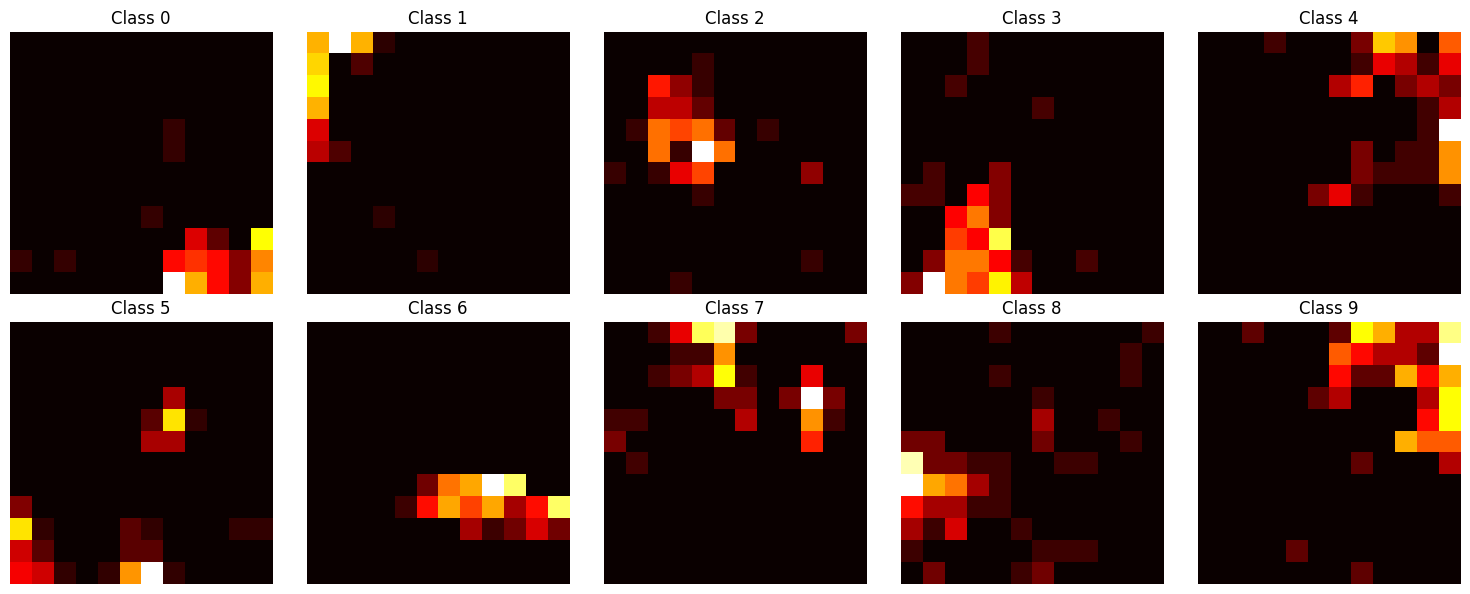

In [22]:
class_activity = som.test(X_test_norm, Y_test)
som.plot_activity_maps(class_activity)

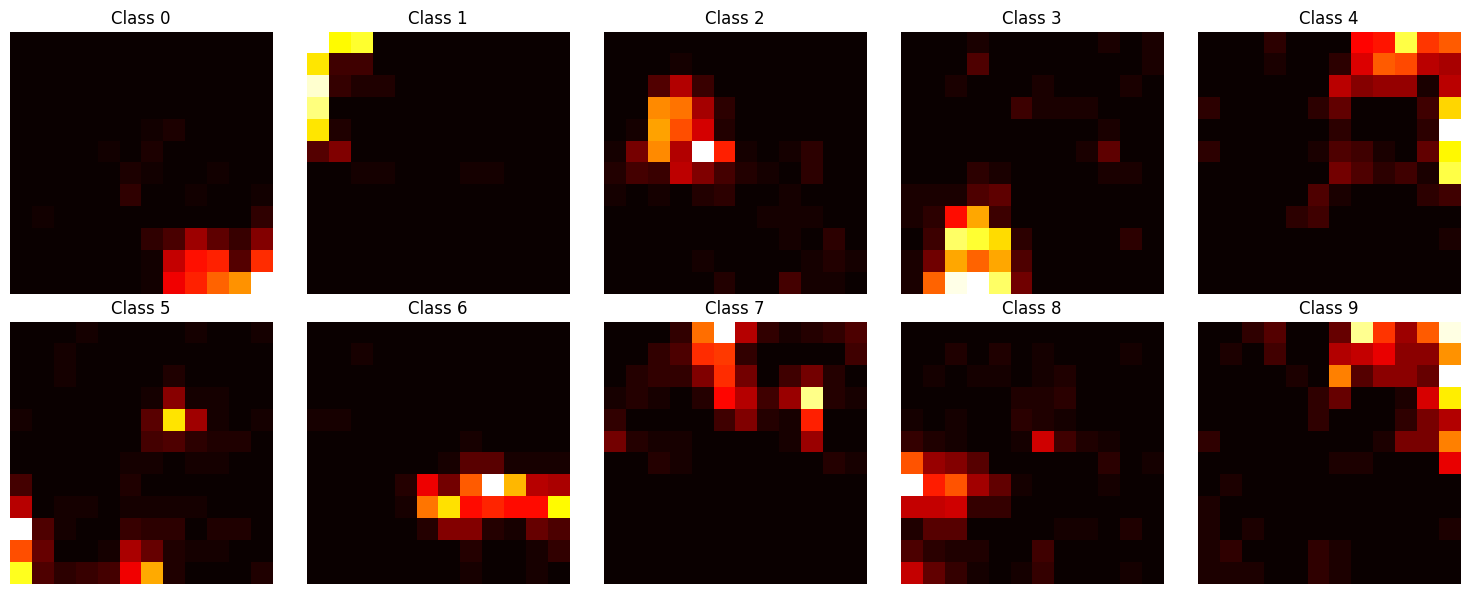

In [24]:
class_activity = som.test(X_train_norm, Y_train)
som.plot_activity_maps(class_activity)

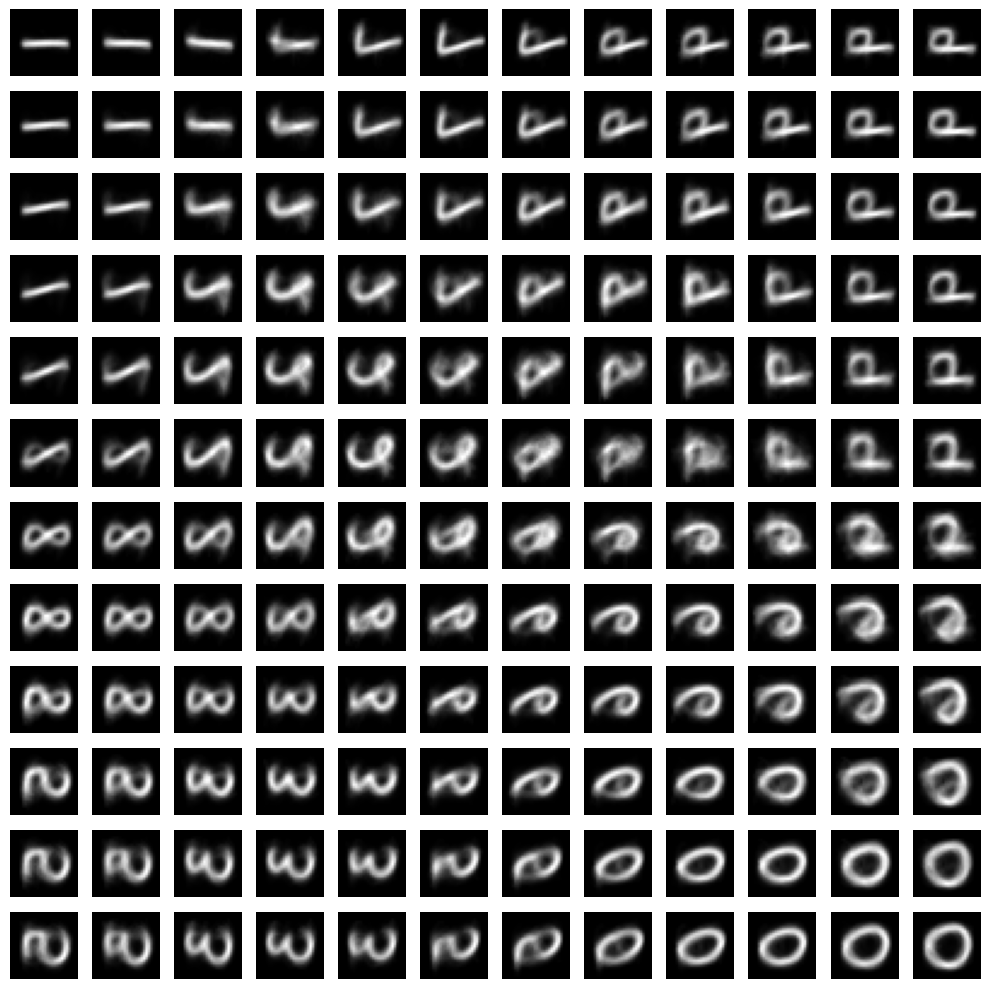

In [25]:
som.plot_weight_grid()

## Problem 3 - SOFM + Sigmoid

In [26]:

class OutputLayer:
    def __init__(self, sofm, lr=0.5, momentum=0.0, use_gaussian=True):
        self.sofm = sofm
        self.lr = lr
        self.momentum = momentum
        self.use_gaussian = use_gaussian
        
        # Simpler initialization - no fancy sigma for now
        # Weight shape: (num_neurons, 10)
        self.W_out = np.random.randn(self.sofm.num_neurons, 10) * 0.01
        self.b_out = np.zeros(10)
        
        self.dW_prev = np.zeros_like(self.W_out)
        self.db_prev = np.zeros_like(self.b_out)
    
    def compute_feature_vector(self, x):
        """
        Two modes:
        1. Simple BMU one-hot (baseline)
        2. Gaussian activation (if use_gaussian=True)
        """
        bmu = self.sofm.find_bmu(x)
        
        if not self.use_gaussian:
            # Simple one-hot baseline
            phi = np.zeros(self.sofm.num_neurons)
            phi[bmu] = 1.0
            return phi
        else:
            # Gaussian with fixed sigma
            bmu_pos = self.sofm.positions[bmu]
            dists = np.linalg.norm(self.sofm.positions - bmu_pos, axis=1)
            phi = np.exp(-(dists ** 2) / (2 * (2.0 ** 2)))
            phi = phi / (np.sum(phi) + 1e-10)
            return phi
    
    def classifier_forward(self, features):
        """Simple linear + sigmoid"""
        logits = features @ self.W_out + self.b_out
        logits = np.clip(logits, -20, 20)  # prevent overflow
        probs = 1 / (1 + np.exp(-logits))
        return probs
    
    def train_classifier(self, train_data, train_labels, test_data, test_labels, epochs=50, verbose=True):
        train_acc_hist = []
        test_acc_hist = []
        
        # Initial diagnostic
        if verbose:
            print("\n=== DIAGNOSTIC INFO ===")
            print(f"SOFM shape: {self.sofm.rows}x{self.sofm.cols} = {self.sofm.num_neurons} neurons")
            print(f"Weight matrix: {self.W_out.shape}")
            print(f"Learning rate: {self.lr}, Momentum: {self.momentum}")
            print(f"Use Gaussian features: {self.use_gaussian}")
            
            # Check SOFM organization
            sample_phi = self.compute_feature_vector(train_data[0])
            print(f"Sample feature vector sum: {np.sum(sample_phi):.4f}")
            print(f"Sample feature non-zeros: {np.sum(sample_phi > 0.01)}")
            print("=" * 40 + "\n")
        
        for epoch in range(epochs):
            # Shuffle
            indices = np.random.permutation(len(train_data))
            
            epoch_loss = 0.0
            for idx in indices:
                x, y = train_data[idx], train_labels[idx]
                
                # Forward
                phi = self.compute_feature_vector(x)
                probs = self.classifier_forward(phi)
                
                # Target
                t = np.zeros(10)
                t[y] = 1.0
                
                # Cross-entropy loss (for monitoring)
                loss = -np.sum(t * np.log(probs + 1e-10))
                epoch_loss += loss
                
                # Gradient (derivative of cross-entropy w/ sigmoid = probs - target)
                error = probs - t
                
                # Compute gradients
                grad_W = np.outer(phi, error)
                grad_b = error
                
                # Simple SGD update (momentum optional)
                if self.momentum > 0:
                    dW = self.lr * grad_W + self.momentum * self.dW_prev
                    db = self.lr * grad_b + self.momentum * self.db_prev
                    self.dW_prev = dW
                    self.db_prev = db
                else:
                    dW = self.lr * grad_W
                    db = self.lr * grad_b
                
                self.W_out -= dW
                self.b_out -= db
            
            # Evaluate
            train_acc = self.evaluate(train_data, train_labels)
            test_acc = self.evaluate(test_data, test_labels)
            train_acc_hist.append(train_acc)
            test_acc_hist.append(test_acc)
            
            if verbose and (epoch % 5 == 0 or epoch < 5):
                avg_loss = epoch_loss / len(train_data)
                print(f"Epoch {epoch+1:3d}/{epochs} | Loss: {avg_loss:.4f} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")
        
        return train_acc_hist, test_acc_hist
    
    def predict(self, x):
        phi = self.compute_feature_vector(x)
        probs = self.classifier_forward(phi)
        return np.argmax(probs)
    
    def evaluate(self, data, labels):
        correct = 0
        for x, y in zip(data, labels):
            if self.predict(x) == y:
                correct += 1
        return correct / len(labels)
    
    def plot_output_weight_maps(self):
        """Plot output weights as heatmaps"""
        fig, axes = plt.subplots(2, 5, figsize=(15, 6))
        for j in range(10):
            ax = axes[j // 5, j % 5]
            heat = self.W_out[:, j].reshape(self.sofm.rows, self.sofm.cols)
            im = ax.imshow(heat, cmap="RdBu_r", vmin=-np.abs(heat).max(), vmax=np.abs(heat).max())
            ax.set_title(f"Class {j}")
            ax.axis('off')
            plt.colorbar(im, ax=ax, fraction=0.046)
        plt.tight_layout()
        plt.show()
    
    def diagnose_sofm(self, data, labels):
        """
        Check if the SOFM actually separated the classes
        """
        print("\n=== SOFM Class Separation Analysis ===")
        
        # For each class, find which neurons fire most
        class_bmus = {i: [] for i in range(10)}
        for x, y in zip(data, labels):
            bmu = self.sofm.find_bmu(x)
            class_bmus[y].append(bmu)
        
        # Check overlap
        for c in range(10):
            unique_bmus = len(set(class_bmus[c]))
            print(f"Class {c}: activates {unique_bmus} unique neurons")
        
        # Check if different classes activate same neurons (bad!)
        all_bmus = [set(class_bmus[c]) for c in range(10)]
        overlaps = 0
        for i in range(10):
            for j in range(i+1, 10):
                overlap = len(all_bmus[i] & all_bmus[j])
                if overlap > 0:
                    overlaps += overlap
        
        print(f"\nTotal BMU overlaps between classes: {overlaps}")
        print("(Lower is better - means SOFM separated classes well)\n")
        
        return class_bmus

In [31]:
# After training your SOFM
output_layer = OutputLayer(som, lr=0.1, momentum=0.0, use_gaussian=False)


In [32]:
output_layer.diagnose_sofm(X_train_norm, Y_train)


=== SOFM Class Separation Analysis ===
Class 0: activates 30 unique neurons
Class 1: activates 19 unique neurons
Class 2: activates 49 unique neurons
Class 3: activates 47 unique neurons
Class 4: activates 47 unique neurons
Class 5: activates 59 unique neurons
Class 6: activates 38 unique neurons
Class 7: activates 51 unique neurons
Class 8: activates 61 unique neurons
Class 9: activates 54 unique neurons

Total BMU overlaps between classes: 628
(Lower is better - means SOFM separated classes well)



{0: [89,
  140,
  119,
  141,
  142,
  143,
  131,
  141,
  141,
  143,
  142,
  139,
  143,
  142,
  142,
  141,
  127,
  130,
  128,
  131,
  119,
  131,
  140,
  117,
  119,
  127,
  130,
  128,
  131,
  128,
  141,
  143,
  127,
  140,
  129,
  115,
  118,
  141,
  129,
  114,
  142,
  89,
  142,
  114,
  128,
  140,
  131,
  130,
  140,
  143,
  139,
  142,
  140,
  92,
  116,
  129,
  117,
  141,
  143,
  143,
  142,
  129,
  142,
  129,
  139,
  131,
  128,
  128,
  128,
  141,
  128,
  119,
  131,
  140,
  140,
  128,
  142,
  128,
  131,
  143,
  143,
  143,
  131,
  116,
  142,
  129,
  141,
  143,
  129,
  140,
  131,
  55,
  142,
  143,
  127,
  143,
  129,
  140,
  116,
  115,
  127,
  107,
  115,
  118,
  128,
  117,
  141,
  129,
  141,
  141,
  77,
  142,
  142,
  129,
  140,
  127,
  117,
  115,
  142,
  141,
  126,
  114,
  129,
  127,
  54,
  142,
  143,
  140,
  130,
  143,
  131,
  140,
  143,
  131,
  138,
  143,
  142,
  141,
  143,
  143,
  143,
  131,
  131,
  

In [33]:
# Train with verbose output
train_acc, test_acc = output_layer.train_classifier(
    X_train_norm, Y_train, 
    X_test_norm, Y_test, 
    epochs=50, 
)


=== DIAGNOSTIC INFO ===
SOFM shape: 12x12 = 144 neurons
Weight matrix: (144, 10)
Learning rate: 0.1, Momentum: 0.0
Use Gaussian features: False
Sample feature vector sum: 1.0000
Sample feature non-zeros: 1

Epoch   1/50 | Loss: 1.6403 | Train Acc: 0.7642 | Test Acc: 0.7550
Epoch   2/50 | Loss: 1.1033 | Train Acc: 0.7750 | Test Acc: 0.7610
Epoch   3/50 | Loss: 0.9233 | Train Acc: 0.7740 | Test Acc: 0.7710
Epoch   4/50 | Loss: 0.8371 | Train Acc: 0.7742 | Test Acc: 0.7640
Epoch   5/50 | Loss: 0.7851 | Train Acc: 0.7750 | Test Acc: 0.7730
Epoch   6/50 | Loss: 0.7528 | Train Acc: 0.7765 | Test Acc: 0.7690
Epoch  11/50 | Loss: 0.6766 | Train Acc: 0.7765 | Test Acc: 0.7620
Epoch  16/50 | Loss: 0.6469 | Train Acc: 0.7760 | Test Acc: 0.7660
Epoch  21/50 | Loss: 0.6323 | Train Acc: 0.7750 | Test Acc: 0.7540
Epoch  26/50 | Loss: 0.6235 | Train Acc: 0.7758 | Test Acc: 0.7710
Epoch  31/50 | Loss: 0.6156 | Train Acc: 0.7748 | Test Acc: 0.7570
Epoch  36/50 | Loss: 0.6121 | Train Acc: 0.7760 | Test 

In [34]:
output_layer.evaluate(X_test_norm, Y_test)

0.766

In [53]:
index = random.randint(0,999)

input = X_test_norm[index]
output = output_layer.predict(input)

print(f"Model output: {output}, True label: {Y_test[index]}")

Model output: 7, True label: 7


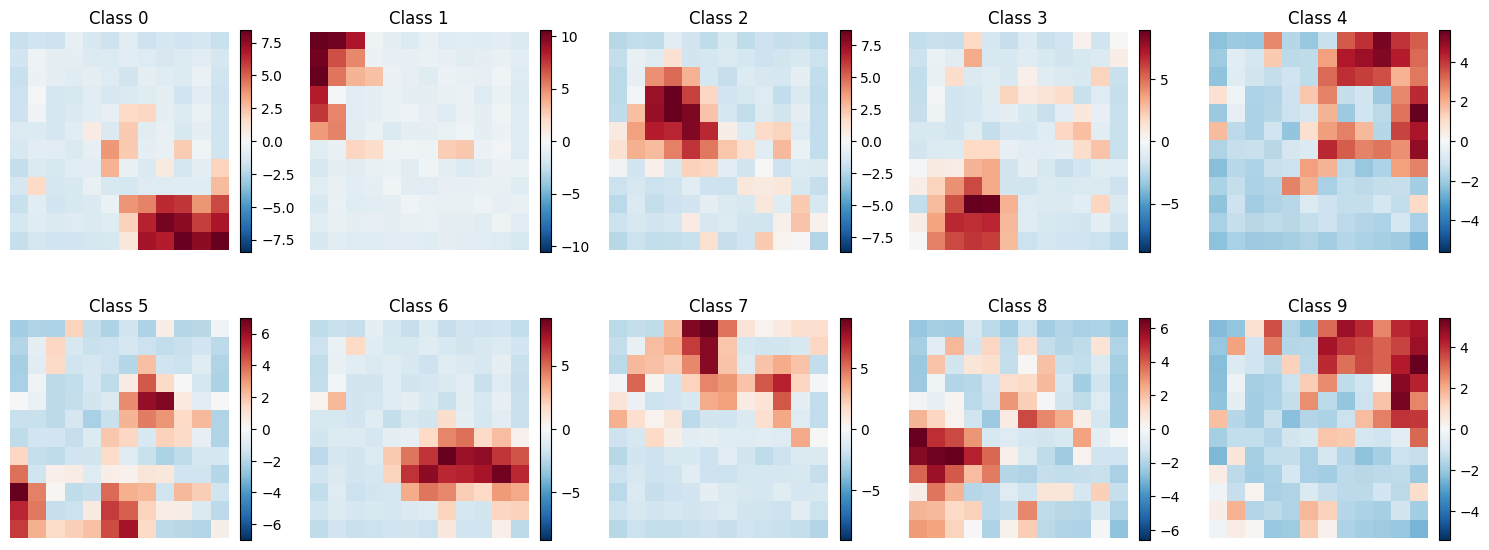

In [35]:
output_layer.plot_output_weight_maps()

In [54]:
def make_confusion_matrix(model, data, labels):
    """
    Create confusion matrix for the classifier
    
    Args:
        model: OutputLayer with predict() method
        data: input data (should be normalized same as training)
        labels: true labels
    
    Returns:
        confusion_matrix: 10x10 numpy array where [i,j] = count of true class i predicted as j
    """
    confusion = np.zeros((10, 10), dtype=int)
    
    for x, true_label in zip(data, labels):
        pred_label = model.predict(x)
        confusion[true_label, pred_label] += 1
    
    return confusion


def plot_confusion_matrix(confusion, normalize=False):
    """
    Plot the confusion matrix as a heatmap
    
    Args:
        confusion: 10x10 confusion matrix
        normalize: if True, normalize rows to show percentages
    """
    if normalize:
        # Normalize by row (true class)
        confusion_norm = confusion.astype(float)
        for i in range(10):
            row_sum = confusion[i].sum()
            if row_sum > 0:
                confusion_norm[i] = confusion[i] / row_sum
        data_to_plot = confusion_norm
        fmt = '.2f'
        title = 'Confusion Matrix (Normalized)'
    else:
        data_to_plot = confusion
        fmt = 'd'
        title = 'Confusion Matrix (Counts)'
    
    plt.figure(figsize=(10, 8))
    plt.imshow(data_to_plot, cmap='Blues', interpolation='nearest')
    plt.colorbar()
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    
    # Add text annotations
    for i in range(10):
        for j in range(10):
            if normalize:
                text = f'{data_to_plot[i, j]:.2f}'
            else:
                text = f'{data_to_plot[i, j]}'
            color = 'white' if data_to_plot[i, j] > data_to_plot.max()/2 else 'black'
            plt.text(j, i, text, ha='center', va='center', color=color)
    
    plt.xticks(range(10))
    plt.yticks(range(10))
    plt.tight_layout()
    plt.show()


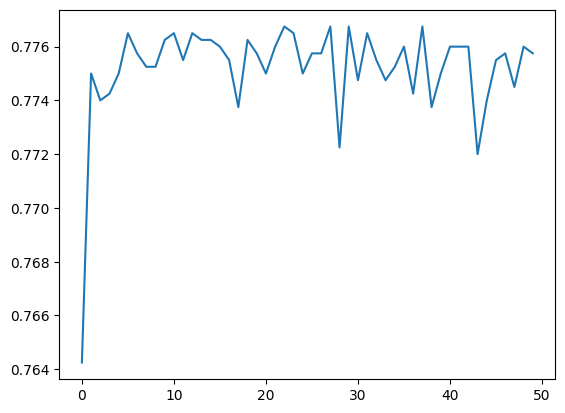

In [37]:
plt.plot(list(range(0, 50)), train_acc)